# Laborator 1 — Rețea neuronală artificială pentru clasificare binară

#### Corețchi Mihai
#### Set de date: `campus_selection.csv`
#### Obiectiv: predicția statutului studentului — **Placed** (plasat) sau **Not Placed** (neplasat).


In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn keras jax jaxlib


## 1. Importul bibliotecilor și încărcarea datelor

In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import keras
from keras import Sequential
from keras.layers import Input, Dense, BatchNormalization, Dropout
from keras.optimizers import Adam

%matplotlib inline
sns.set_theme(style="whitegrid")
keras.utils.set_random_seed(101)


In [3]:
DATA_PATH = Path("campus_selection.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("lab1/campus_selection.csv")

data = pd.read_csv(DATA_PATH)
data.head()


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed


## 2. Analiza exploratorie a datelor

Verificăm dimensiunea setului de date, tipurile coloanelor, valorile lipsă și statistici sumare.


In [4]:
print("Shape:", data.shape)
print("Columns:", list(data.columns))


Shape: (215, 14)
Columns: ['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status']


In [5]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    str    
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    str    
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    str    
 6   hsc_s           215 non-null    str    
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    str    
 9   workex          215 non-null    str    
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    str    
 12  mba_p           215 non-null    float64
 13  status          215 non-null    str    
dtypes: float64(5), int64(1), str(8)
memory usage: 23.6 KB


In [6]:
data.describe()


,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000


In [7]:
data.isnull().sum()


sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
dtype: int64

Coloana țintă este `status`. Are două clase, deci avem o problemă de **clasificare binară**.


In [8]:
data["status"].value_counts()


status
Placed        148
Not Placed     67
Name: count, dtype: int64

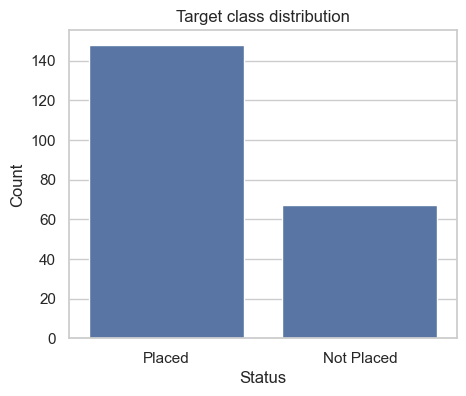

In [9]:
plt.figure(figsize=(5, 4))
sns.countplot(data=data, x="status")
plt.title("Target class distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()


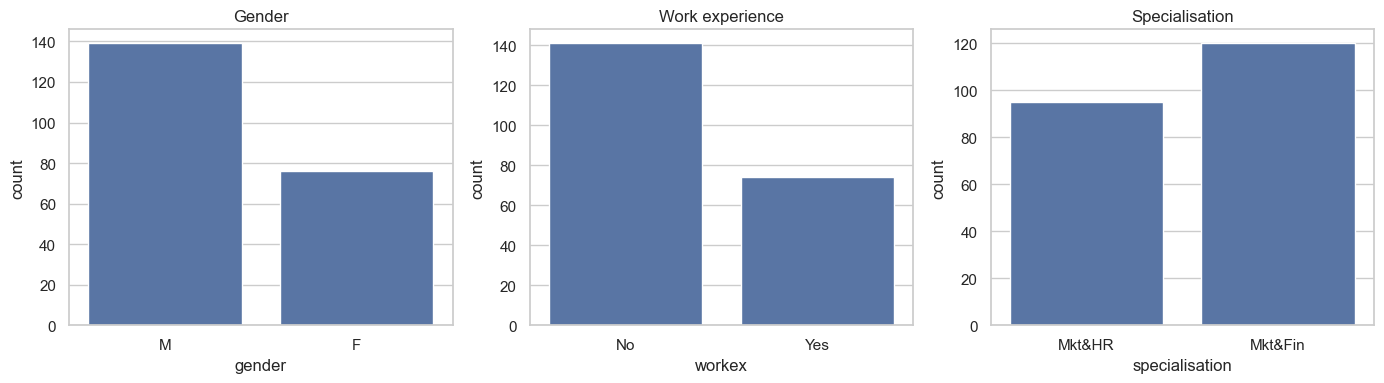

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=data, x="gender", ax=axes[0])
axes[0].set_title("Gender")

sns.countplot(data=data, x="workex", ax=axes[1])
axes[1].set_title("Work experience")

sns.countplot(data=data, x="specialisation", ax=axes[2])
axes[2].set_title("Specialisation")

plt.tight_layout()
plt.show()


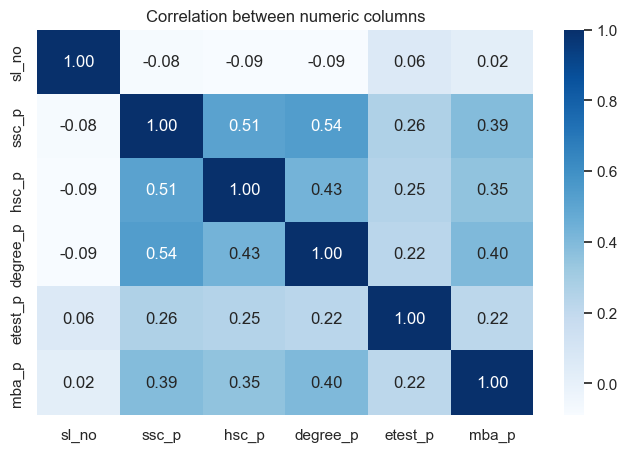

In [11]:
numeric_data = data.select_dtypes(include="number")

plt.figure(figsize=(8, 5))
sns.heatmap(numeric_data.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation between numeric columns")
plt.show()


## 3. Curățarea și codificarea datelor

Eliminăm `sl_no`, deoarece este doar un identificator.

Coloanele text sunt convertite în valori numerice cu `LabelEncoder`.


In [ ]:
clean_data = data.drop(columns=["sl_no"])

text_columns = clean_data.select_dtypes(include="object").columns
label_encoders = {}

for column in text_columns:
    encoder = LabelEncoder()
    clean_data[column] = encoder.fit_transform(clean_data[column])
    label_encoders[column] = encoder

print("Columns encoded:", list(text_columns))
clean_data.head()


Columns encoded with LabelEncoder: ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation', 'status']


/var/folders/xs/x0_1wjzd7pl8h4gdcpsk5bv40000gn/T/ipykernel_69921/1166556222.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = clean_data.select_dtypes(include="object").columns


,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,1,67.00,1,91.00,1,1,58.00,2,0,55.0,1,58.80,1
1,1,79.33,0,78.33,1,2,77.48,2,1,86.5,0,66.28,1
2,1,65.00,0,68.00,0,0,64.00,0,0,75.0,0,57.80,1
3,1,56.00,0,52.00,0,2,52.00,2,0,66.0,1,59.43,0
4,1,85.80,0,73.60,0,1,73.30,0,0,96.8,0,55.50,1


In [13]:
print("Encoded values for target column:")
for value, code_value in zip(label_encoders["status"].classes_, label_encoders["status"].transform(label_encoders["status"].classes_)):
    print(f"{value} -> {code_value}")


Encoded values for target column:
Not Placed -> 0
Placed -> 1


## 4. Date de antrenament și de test

`X` conține atributele de intrare.

`y` conține variabila țintă: statutul de plasare.

Folosim **70%** din date pentru antrenament și **30%** pentru testare.


In [14]:
X = clean_data.drop(columns=["status"])
y = clean_data["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=101,
    stratify=y,
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Train classes:")
print(y_train.value_counts())
print("Test classes:")
print(y_test.value_counts())


Training data: (150, 12)
Testing data: (65, 12)
Train classes:
status
1    103
0     47
Name: count, dtype: int64
Test classes:
status
1    45
0    20
Name: count, dtype: int64


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype("float32")
X_test_scaled = scaler.transform(X_test).astype("float32")

y_train_array = y_train.to_numpy().astype("float32")
y_test_array = y_test.to_numpy().astype("float32")


## 5. Crearea și antrenarea modelului RNR de bază

Construim un model `Sequential`, adăugăm stratul de intrare, straturi ascunse `Dense` și un strat final cu **sigmoid** pentru predicție binară (0/1).


In [16]:
input_size = X_train_scaled.shape[1]

baseline_model = Sequential([
    Input(shape=(input_size,)),
    Dense(8, activation="relu"),
    Dense(4, activation="relu"),
    Dense(1, activation="sigmoid"),
])


Afișăm rezumatul modelului pentru a vedea structura rețelei.


In [17]:
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145 (580.00 B)

 Trainable params: 145 (580.00 B)

 Non-trainable params: 0 (0.00 B)

Declarăm optimizatorul și compilăm modelul.


In [18]:
baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["binary_accuracy"],
)


Antrenăm modelul și salvăm valorile în obiectul `history`.


In [19]:
history = baseline_model.fit(
    X_train_scaled,
    y_train_array,
    validation_data=(X_test_scaled, y_test_array),
    epochs=50,
    batch_size=16,
    verbose=0,
)

history_df = pd.DataFrame(history.history)
history_df.tail()


,binary_accuracy,loss,val_binary_accuracy,val_loss
45,0.753333,0.399100,0.738462,0.469071
46,0.760000,0.394768,0.753846,0.465497
47,0.773333,0.390414,0.753846,0.460459
48,0.780000,0.385535,0.769231,0.456536
49,0.800000,0.381350,0.769231,0.451288


## 6. Acuratețe și pierdere în funcție de epocă

Graficele ilustrează evoluția învățării în timpul antrenării.


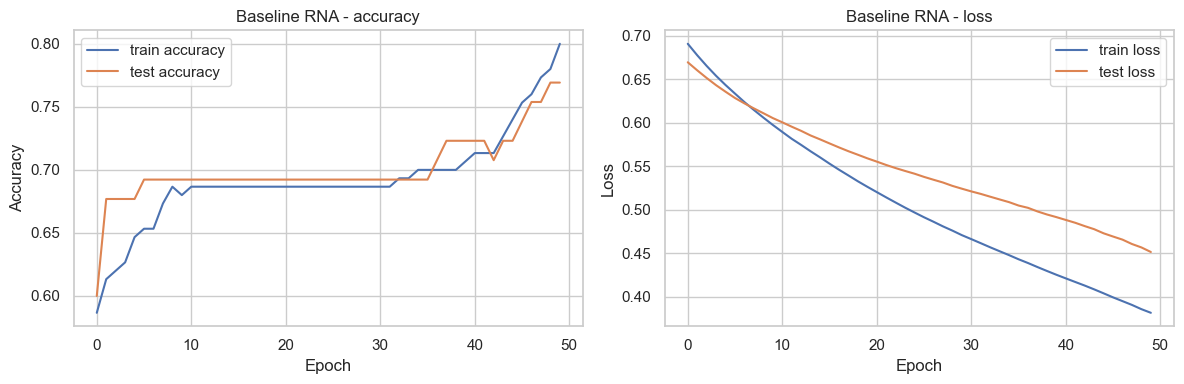

In [20]:
def plot_history(history, title):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["binary_accuracy"], label="train accuracy")
    axes[0].plot(history_df["val_binary_accuracy"], label="test accuracy")
    axes[0].set_title(f"{title} - accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history_df["loss"], label="train loss")
    axes[1].plot(history_df["val_loss"], label="test loss")
    axes[1].set_title(f"{title} - loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history, "Baseline RNA")


## 7. Evaluarea modelului de bază

Evaluăm modelul folosind **acuratețea**, **matricea de confuzie** și **raportul de clasificare**.


Baseline RNA model
Accuracy: 0.769

Classification report:
              precision    recall  f1-score   support

  Not Placed       0.86      0.30      0.44        20
      Placed       0.76      0.98      0.85        45

    accuracy                           0.77        65
   macro avg       0.81      0.64      0.65        65
weighted avg       0.79      0.77      0.73        65



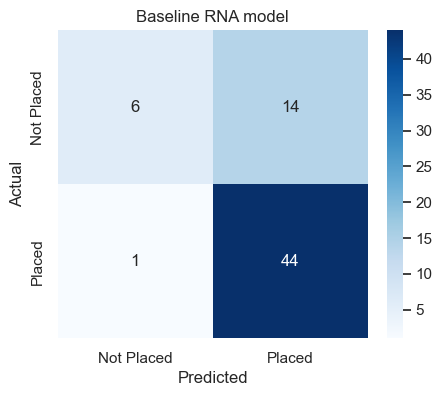

In [21]:
def evaluate_model(model, X_test_scaled, y_test, title):
    probabilities = model.predict(X_test_scaled, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    matrix = confusion_matrix(y_test, predictions)

    print(title)
    print("Accuracy:", round(accuracy, 3))
    print()
    print("Classification report:")
    print(classification_report(y_test, predictions, target_names=label_encoders["status"].classes_))

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoders["status"].classes_,
        yticklabels=label_encoders["status"].classes_,
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return accuracy


baseline_accuracy = evaluate_model(
    baseline_model,
    X_test_scaled,
    y_test,
    "Baseline RNA model",
)


## 8. Optimizarea modelului RNR

Setul de date este **dezechilibrat**: există mai mulți studenți cu eticheta `Placed` decât `Not Placed`.

Pentru optimizare folosim:

- `compute_class_weight` pentru a acorda o pondere mai mare clasei minoritare
- mai mulți neuroni în straturile ascunse
- **Batch Normalization**
- **Dropout**

Ultimul strat rămâne cu **sigmoid**, întrucât problema este de clasificare binară.


In [22]:
improved_model = Sequential([
    Input(shape=(input_size,)),
    Dense(16, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid"),
])

improved_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 32 (128.00 B)

In [23]:
class_labels = np.unique(y_train_array)
weights = compute_class_weight(
    class_weight="balanced",
    classes=class_labels,
    y=y_train_array,
)
class_weight = {int(label): float(weight) for label, weight in zip(class_labels, weights)}

print("Class weights:", class_weight)

improved_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["binary_accuracy"],
)

improved_history = improved_model.fit(
    X_train_scaled,
    y_train_array,
    validation_data=(X_test_scaled, y_test_array),
    epochs=70,
    batch_size=16,
    class_weight=class_weight,
    verbose=0,
)

pd.DataFrame(improved_history.history).tail()


Class weights: {0: 1.5957446808510638, 1: 0.7281553398058253}


,binary_accuracy,loss,val_binary_accuracy,val_loss
65,0.880000,0.254515,0.846154,0.407100
66,0.853333,0.256069,0.846154,0.409053
67,0.880000,0.287064,0.846154,0.411828
68,0.846667,0.307165,0.846154,0.409522
69,0.886667,0.278486,0.846154,0.406405


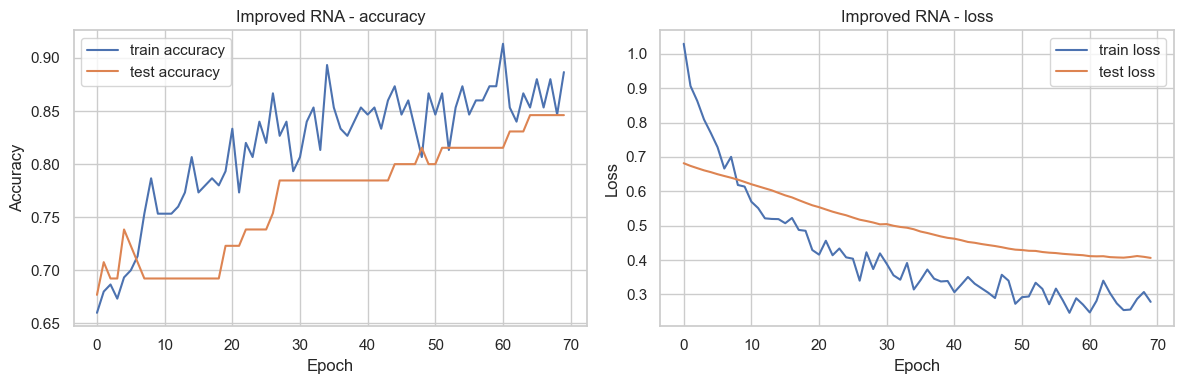

In [24]:
plot_history(improved_history, "Improved RNA")


Improved RNA model
Accuracy: 0.846

Classification report:
              precision    recall  f1-score   support

  Not Placed       0.75      0.75      0.75        20
      Placed       0.89      0.89      0.89        45

    accuracy                           0.85        65
   macro avg       0.82      0.82      0.82        65
weighted avg       0.85      0.85      0.85        65



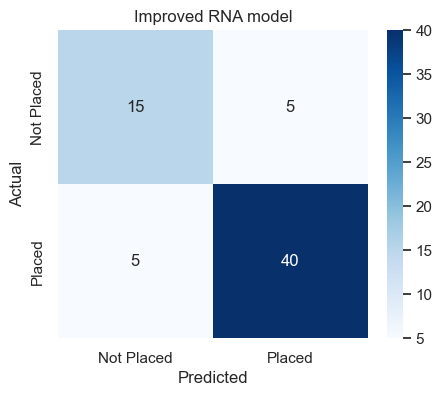

In [25]:
improved_accuracy = evaluate_model(
    improved_model,
    X_test_scaled,
    y_test,
    "Improved RNA model",
)


## 9. Compararea modelelor

Tabelul arată dacă modelul optimizat îmbunătățește acuratețea pe setul de test.


In [26]:
comparison = pd.DataFrame({
    "model": ["Baseline", "Improved"],
    "accuracy": [baseline_accuracy, improved_accuracy],
})

best_model = comparison.loc[comparison["accuracy"].idxmax(), "model"]
print("Best model by accuracy:", best_model)

comparison


Best model by accuracy: Improved


,model,accuracy
0,Baseline,0.769231
1,Improved,0.846154


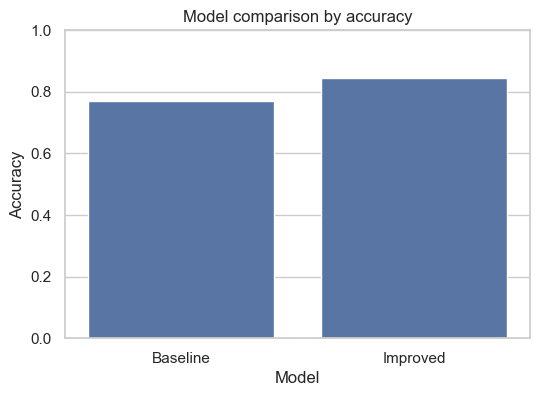

In [27]:
plt.figure(figsize=(6, 4))
sns.barplot(data=comparison, x="model", y="accuracy")
plt.ylim(0, 1)
plt.title("Model comparison by accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.show()


## 10. Concluzii

În cadrul acestui laborator am construit și optimizat o rețea neuronală artificială cu straturi dense pentru predicția statutului de plasare al studenților. Fluxul de lucru a inclus preprocesarea datelor, codificarea variabilelor categorice, scalarea numerelor, antrenarea și testarea modelului, precum și evaluarea performanței.

Modelul inițial a obținut o acuratețe de circa **77%**, iar modelul optimizat a ridicat rezultatul la circa **85%**. Îmbunătățirea principală constă în capacitatea modelului de a clasifica mai balansat atât studenții **Placed**, cât și pe cei **Not Placed**. Primul model era atras spre clasa majoritară; varianta optimizată a redus acest dezechilibru prin **ponderi pe clase**, **Batch Normalization** și **Dropout**.

În ansamblu, rețeaua optimizată oferă rezultate mai bune și mai echilibrate. Acest lucru arată că evaluarea nu trebuie să se bazeze doar pe acuratețe, ci și pe **precizie, recall, scorul F1 și matricea de confuzie**, mai ales când setul de date conține clase dezechilibrate.


#### 1. Care sunt pașii de creare a unei rețele neuronale artificiale? Explicați modelul perceptronului.

Pașii generali sunt:

1. **Definirea problemei**
   Se stabilește dacă problema este de clasificare, regresie, recunoaștere de imagini, predicție etc.

2. **Colectarea și pregătirea datelor**
   Datele se curăță, se normalizează, se împart în seturi de antrenare, validare și testare.

3. **Alegerea arhitecturii RNA**
   Se stabilesc numărul de straturi, numărul de neuroni pe strat și tipurile de straturi folosite.

4. **Alegerea funcțiilor de activare**
   Acestea introduc neliniaritate în model și permit rețelei să învețe relații complexe.

5. **Alegerea funcției loss**
   Funcția loss măsoară diferența dintre predicțiile modelului și valorile reale.

6. **Alegerea optimizatorului**
   Optimizatorul ajustează ponderile rețelei pentru a reduce eroarea.

7. **Antrenarea modelului**
   Modelul procesează datele, calculează eroarea și își actualizează ponderile prin backpropagation.

8. **Evaluarea modelului**
   Se folosesc metrici precum accuracy, precision, recall, F1-score, MAE, RMSE etc.

9. **Optimizarea modelului**
   Se ajustează hiperparametrii, arhitectura, rata de învățare, dropout-ul și alte componente.

**Perceptronul** este cel mai simplu model de neuron artificial. El primește mai multe intrări, fiecare intrare are o pondere, apoi se calculează suma ponderată:

[
z = w_1x_1 + w_2x_2 + ... + w_nx_n + b
]

unde:

* (x_i) sunt valorile de intrare;
* (w_i) sunt ponderile;
* (b) este bias-ul;
* (z) este rezultatul intermediar.

Apoi rezultatul trece printr-o funcție de activare, care decide ieșirea neuronului. În perceptronul clasic, funcția de activare este de tip prag: dacă valoarea depășește un anumit prag, ieșirea este 1, altfel este 0.


#### 2. Cum determinăm numărul de straturi de neuroni?

Numărul de straturi se determină în funcție de complexitatea problemei și de cantitatea de date disponibile.

Pentru probleme simple, poate fi suficient un singur strat ascuns. Pentru probleme mai complexe, cum ar fi procesarea imaginilor, limbajului natural sau clasificarea avansată, se folosesc mai multe straturi.

În practică, nu există o formulă exactă. Se începe de obicei cu o arhitectură simplă, apoi se crește treptat complexitatea dacă modelul nu învață suficient de bine. Dacă modelul are prea puține straturi, apare **underfitting**. Dacă are prea multe straturi, poate apărea **overfitting**.



#### 3. Cum alegem funcția de activare?

Funcția de activare se alege în funcție de tipul stratului și de problema rezolvată.

Pentru straturile ascunse, cea mai folosită funcție este **ReLU**, deoarece este simplă, rapidă și funcționează bine în multe rețele neuronale.

[
ReLU(x) = max(0, x)
]

Pentru stratul de ieșire:

* **Sigmoid** se folosește pentru clasificare binară;
* **Softmax** se folosește pentru clasificare multi-clasă;
* **Linear** se folosește pentru regresie, când trebuie prezisă o valoare numerică.

Funcțiile **tanh** sau **Leaky ReLU** pot fi folosite în cazuri speciale, mai ales când ReLU produce prea mulți neuroni inactivi.


#### 4. Ce calculează funcția loss?

Funcția **loss** calculează eroarea dintre predicția modelului și valoarea reală.

Cu alte cuvinte, ea arată cât de mult greșește rețeaua neuronală. Scopul antrenării este minimizarea acestei funcții.

Exemple:

* Pentru regresie se folosesc frecvent **Mean Squared Error** sau **Mean Absolute Error**.
* Pentru clasificare binară se folosește **Binary Cross-Entropy**.
* Pentru clasificare multi-clasă se folosește **Categorical Cross-Entropy** sau **Sparse Categorical Cross-Entropy**.

O valoare loss mai mică indică, în general, un model mai bun, dar trebuie verificată și performanța pe date de validare/testare.

#### 5. Explicați gradientul de coborâre. Ce rată de învățare e recomandată?

**Gradientul de coborâre** este metoda prin care rețeaua își ajustează ponderile pentru a reduce eroarea.

Modelul calculează direcția în care funcția loss crește cel mai mult, apoi actualizează ponderile în direcția opusă, pentru a reduce eroarea.


**Rata de învățare** controlează cât de mari sunt pașii făcuți la fiecare actualizare.

O valoare recomandată ca punct de pornire este:

[
\alpha = 0.001
]

Mai ales când se folosește optimizatorul **Adam**. Dacă rata este prea mare, modelul poate deveni instabil. Dacă este prea mică, antrenarea va fi foarte lentă.


#### 6. Cum ne ajută optimizatorii?

Optimizatorii ajută la actualizarea eficientă a ponderilor rețelei neuronale pentru a minimiza funcția loss.

Ei îmbunătățesc procesul de învățare prin:

* ajustarea direcției de actualizare a ponderilor;
* adaptarea ratei de învățare;
* accelerarea convergenței;
* reducerea riscului de blocare în zone nefavorabile ale funcției loss.

Exemple de optimizatori:

* **SGD** — simplu, dar poate fi mai lent;
* **SGD cu momentum** — ajută modelul să avanseze mai stabil;
* **RMSprop** — adaptează rata de învățare pentru fiecare parametru;
* **Adam** — una dintre cele mai folosite metode, deoarece combină avantajele momentum și RMSprop.

În practică, **Adam cu learning rate 0.001** este un punct de pornire foarte bun.



#### 7. Când și cu ce scop folosim straturile de abandon? Ce rată de abandon e recomandată?

Straturile de abandon, adică **Dropout Layers**, se folosesc pentru a reduce **overfitting-ul**.

În timpul antrenării, dropout dezactivează aleatoriu o parte dintre neuroni. Astfel, rețeaua nu mai depinde excesiv de anumiți neuroni și învață reprezentări mai robuste.

Dropout se folosește de obicei:

* în rețele dense;
* când modelul are performanță bună pe datele de antrenare, dar slabă pe datele de validare;
* când există risc de memorare a datelor.

O rată recomandată este:

[
0.2 - 0.5
]

De obicei:

* **0.2** este potrivit pentru modele mai mici;
* **0.5** este folosit mai ales în straturi dense mari;
* pentru rețele convoluționale se folosesc adesea valori mai mici, de exemplu **0.1–0.3**.



## 8. Care e scopul normalizării loturilor?

**Batch Normalization** normalizează valorile intermediare din rețea pentru fiecare mini-batch.

Scopul este de a stabiliza și accelera antrenarea modelului.

Avantaje:

* reduce variațiile mari ale activărilor;
* permite folosirea unor rate de învățare mai mari;
* accelerează convergența;
* face antrenarea mai stabilă;
* poate avea un efect ușor de regularizare.

Batch Normalization se aplică de obicei între stratul liniar/convoluțional și funcția de activare.



#### 9. Cum evaluăm rezultatele obținute cu ajutorul RNA?

Rezultatele se evaluează pe date care nu au fost folosite la antrenare, de obicei pe setul de testare.

Pentru **clasificare**, se folosesc metrici precum:

* Accuracy;
* Precision;
* Recall;
* F1-score;
* matricea de confuzie;
* ROC-AUC, pentru clasificare binară.

Pentru **regresie**, se folosesc metrici precum:

* MAE;
* MSE;
* RMSE;
* R².

De asemenea, se compară loss-ul pe setul de antrenare și pe setul de validare. Dacă loss-ul pe training scade, dar loss-ul pe validare crește, modelul suferă de **overfitting**.


#### 10. Care sunt pașii de optimizare a unei rețele neuronale?

Pașii principali de optimizare sunt:

1. **Verificarea calității datelor**
   Se elimină erorile, valorile lipsă, duplicatele și valorile extreme problematice.

2. **Normalizarea sau standardizarea datelor**
   Datele trebuie aduse la o scară potrivită pentru ca rețeaua să învețe mai stabil.

3. **Ajustarea arhitecturii**
   Se modifică numărul de straturi, numărul de neuroni și tipurile de straturi.

4. **Alegerea funcției de activare potrivite**
   De exemplu, ReLU pentru straturi ascunse, sigmoid sau softmax pentru clasificare.

5. **Alegerea funcției loss potrivite**
   Funcția loss trebuie să corespundă tipului problemei.

6. **Alegerea optimizatorului**
   Adam este de obicei o alegere bună pentru început.

7. **Ajustarea ratei de învățare**
   Se testează valori precum 0.01, 0.001 sau 0.0001.

8. **Folosirea regularizării**
   Se pot folosi Dropout, L1/L2 regularization sau early stopping.

9. **Aplicarea Batch Normalization**
   Aceasta poate stabiliza și accelera procesul de antrenare.

10. **Monitorizarea performanței**
    Se urmăresc loss-ul și metricile pe training, validation și test.

11. **Testarea finală**
    După alegerea modelului optim, acesta se evaluează pe setul de testare pentru a estima performanța reală.
